In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Input, Dense, Conv2D, Flatten, MaxPooling2D, Dropout)
from tensorflow.keras.utils import to_categorical

In [20]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "images",
    image_size=(64, 64),
    batch_size=None
)

Found 2033 files belonging to 12 classes.


In [21]:
X = []
y = []
for image, label in dataset:
    X.append(image.numpy())
    y.append(label.numpy())

In [23]:
import numpy as np
X = np.array(X)
y = np.array(y)

In [24]:
X.shape

(2033, 64, 64, 3)

In [25]:
y.shape

(2033,)

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
X_train.shape

(1626, 64, 64, 3)

In [29]:
X_train = X_train / 255
X_test = X_test / 255

In [30]:
y_train = to_categorical(y_train, 12)
y_test = to_categorical(y_test, 12)

In [31]:
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

In [33]:
model = Sequential()
model.add(Input(shape=input_shape))

model.add(Conv2D(32, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D(2, 2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(num_classes, activation="softmax"))
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,700 (6.21 MB)

 Trainable params: 1,626,700 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1731 - loss: 2.4068 - val_accuracy: 0.4110 - val_loss: 1.9783
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4808 - loss: 1.6677 - val_accuracy: 0.6503 - val_loss: 1.2453
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6438 - loss: 1.1810 - val_accuracy: 0.7270 - val_loss: 1.0156
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7077 - loss: 0.9786 - val_accuracy: 0.7178 - val_loss: 0.9361
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.7162 - loss: 0.9232 - val_accuracy: 0.7791 - val_loss: 0.7256
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7685 - loss: 0.7873 - val_accuracy: 0.7945 - val_loss: 0.8170
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7938 - loss: 0.6913 - val_accuracy: 0.8129 - val_loss: 0.6655
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8162 - loss: 0.6024 - val_accuracy: 0.8067 - v

In [37]:
# Hyperparameter Tuning
model2 = Sequential()
model2.add(Input(shape=input_shape))

model2.add(Conv2D(32, (3, 3), activation="relu"))
model2.add(MaxPooling2D(2, 2))

model2.add(Conv2D(64, (3, 3), activation="relu"))
model2.add(MaxPooling2D(2, 2))

model2.add(Flatten())

model2.add(Dense(128, activation="relu"))
model2.add(Dropout(0.5))

model2.add(Dense(num_classes, activation="softmax"))
model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history2 = model2.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.1646 - loss: 2.4014 - val_accuracy: 0.3436 - val_loss: 2.0650
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.3915 - loss: 1.8260 - val_accuracy: 0.6074 - val_loss: 1.3870
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5231 - loss: 1.5009 - val_accuracy: 0.6779 - val_loss: 1.1521
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6015 - loss: 1.3165 - val_accuracy: 0.7638 - val_loss: 1.0318
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6392 - loss: 1.1570 - val_accuracy: 0.7699 - val_loss: 0.9044
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6538 - loss: 1.0808 - val_accuracy: 0.7822 - val_loss: 0.8415
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6969 - loss: 0.9822 - val_accuracy: 0.8067 - val_loss: 0.7472
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7146 - loss: 0.9189 - val_accuracy: 0.7883 - v

In [39]:
#uing model 1
y_pred = model.predict(X_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [40]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

In [41]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score, f1_score, classification_report, confusion_matrix)

In [43]:
accuracy = accuracy_score(y_test_classes, y_pred_classes)
accuracy

0.85995085995086

In [44]:
precision = precision_score(y_test_classes, y_pred_classes, average="weighted")
precision

0.8677820028290153

In [45]:
recall = recall_score(y_test_classes, y_pred_classes, average="weighted")
recall

0.85995085995086

In [46]:
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=classes
))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86        19
           1       0.79      0.88      0.83        34
           2       0.79      0.94      0.86        35
           3       0.96      0.73      0.83        37
           4       0.82      0.80      0.81        41
           5       0.86      0.92      0.89        39
           6       0.91      0.94      0.92        32
           7       0.71      0.83      0.77        30
           8       0.96      0.89      0.92        27
           9       0.84      0.84      0.84        25
          ba       0.91      0.95      0.93        41
          pa       0.93      0.79      0.85        47

    accuracy                           0.86       407
   macro avg       0.87      0.86      0.86       407
weighted avg       0.87      0.86      0.86       407



In [48]:
import seaborn as sns

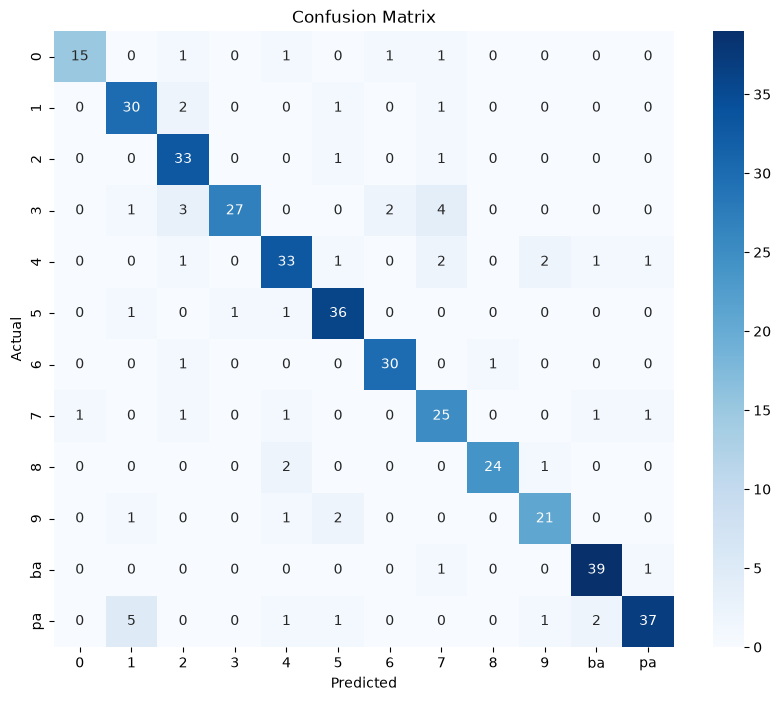

In [49]:
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
# Performance Analysis

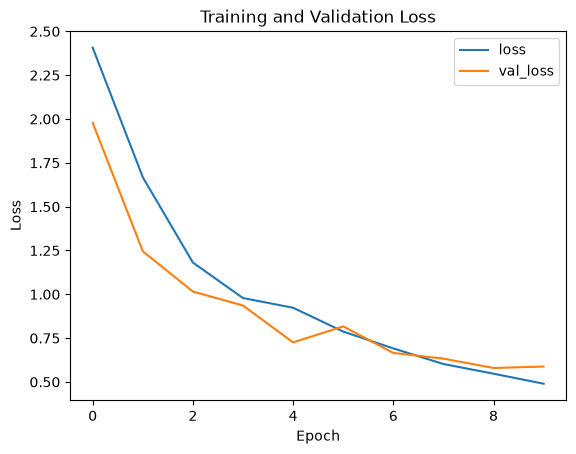

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(history.history)

df[["loss", "val_loss"]].plot(kind="line")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()